# 01, Explore the B11 catalog

Per `plan.md` §10 / §11 step 1. Loads `Data/J_AJ_141_23/table7.dat`,
renders diameter / Vexp / axial-ratio histograms, and breaks the 1046
holes down by hole type (1/2/3) per galaxy. Use this to confirm §2.4
decisions about the type-1 split before locking the LOGO run.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hishells.catalog import load_catalog, LOGO_GALAXIES_19

In [2]:
REPO = Path('..').resolve()
cat = load_catalog(REPO / 'Data' / 'J_AJ_141_23')
holes, gals = cat.holes, cat.galaxies
print(f'{len(holes)} holes across {holes["galaxy_id"].nunique()} galaxies')
print(f'{len(LOGO_GALAXIES_19)} galaxies reachable for LOGO ({set(holes["galaxy_id"]) - set(LOGO_GALAXIES_19)} excluded)')
holes.head()

1046 holes across 20 galaxies
19 galaxies reachable for LOGO ({'IC_2574'} excluded)


,name_b11,galaxy_id,hole_idx,ra_deg,dec_deg,vel_helio_kms,hole_type,diameter_pc,vexp_kms,pa_deg,axial_ratio,gc_radius_kpc,n_HI_raw,t_kin_myr,log_E_J43,log_MHI_1e4Msun,distance_mpc,diameter_arcsec,sigma_gas_kms
0,NGC 628,NGC_628,1,24.083750,15.729222,645.0,1,520.0,7.0,109.0,0.7,13.1,-1.1,36.0,1.2,1.2,7.3,14.692849,10.0
1,NGC 628,NGC_628,2,24.084167,15.752139,650.0,1,849.0,7.0,0.0,1.0,11.8,-1.0,59.0,2.0,1.9,7.3,23.988902,10.0
2,NGC 628,NGC_628,3,24.097500,15.728778,639.0,1,575.0,7.0,149.0,0.5,11.7,-0.9,40.0,1.6,1.6,7.3,16.246901,10.0
3,NGC 628,NGC_628,4,24.100000,15.741694,639.0,2,546.0,10.0,126.0,0.8,10.5,-0.7,27.0,1.9,1.6,7.3,15.427492,10.0
4,NGC 628,NGC_628,5,24.100417,15.848778,665.0,2,459.0,7.0,0.0,0.9,12.4,-0.8,32.0,1.4,1.3,7.3,12.969265,10.0


## Hole-type breakdown

Type 1 = stalled (no measurable Vexp), 2 = one-sided expansion,
3 = two-sided expansion (textbook ellipse). Per §2.4 the v1 default
trains on types {2,3} only, use the bar chart below to confirm that
still leaves enough positives per galaxy.

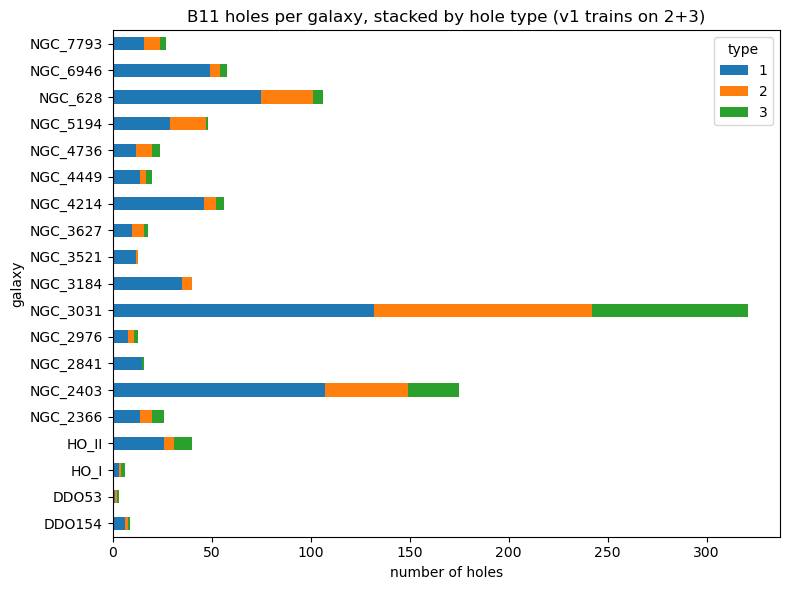

In [3]:
by_type = holes.groupby(['galaxy_id', 'hole_type']).size().unstack(fill_value=0)
by_type = by_type.reindex(LOGO_GALAXIES_19)
ax = by_type.plot.barh(stacked=True, figsize=(8, 6))
ax.set_xlabel('number of holes')
ax.set_ylabel('galaxy')
ax.set_title('B11 holes per galaxy, stacked by hole type (v1 trains on 2+3)')
ax.legend(title='type')
plt.tight_layout()

In [4]:
summary = by_type.copy()
summary['total'] = summary.sum(axis=1)
summary['types_2_3'] = summary.get(2, 0) + summary.get(3, 0)
summary['frac_2_3'] = summary['types_2_3'] / summary['total']
summary.style.format({'frac_2_3': '{:.0%}'})

hole_type,1,2,3,total,types_2_3,frac_2_3
galaxy_id,,,,,,
DDO154,6,2,1,9,3,33%
DDO53,1,1,1,3,2,67%
HO_I,3,1,2,6,3,50%
HO_II,26,5,9,40,14,35%
NGC_2366,14,6,6,26,12,46%
NGC_2403,107,42,26,175,68,39%
NGC_2841,15,0,1,16,1,6%
NGC_2976,8,3,2,13,5,38%
NGC_3031,132,110,79,321,189,59%


## Diameter / Vexp / axial-ratio histograms

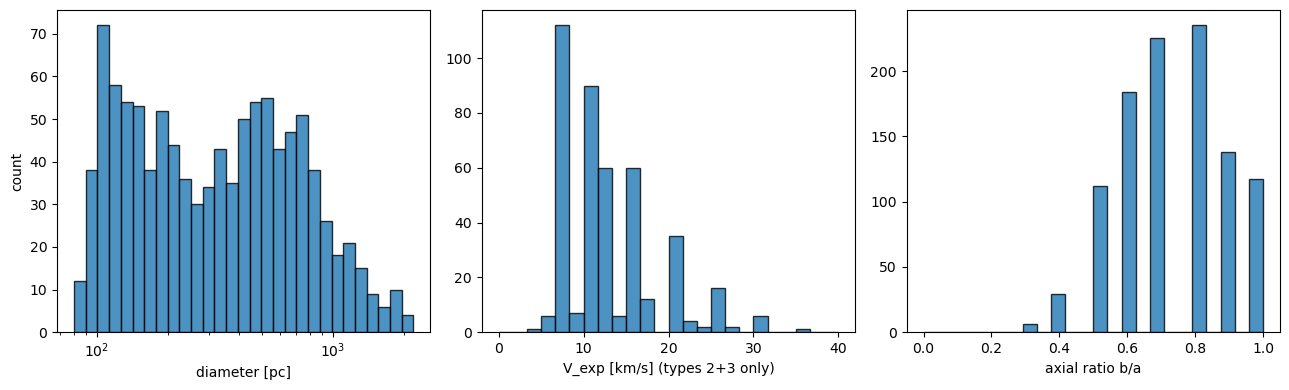

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, label, bins) in zip(
    axes,
    [
        ('diameter_pc', 'diameter [pc]', np.logspace(np.log10(80), np.log10(2200), 30)),
        ('vexp_kms', 'V_exp [km/s] (types 2+3 only)', np.linspace(0, 40, 25)),
        ('axial_ratio', 'axial ratio b/a', np.linspace(0.0, 1.0, 25)),
    ],
):
    sub = holes if col != 'vexp_kms' else holes[holes['hole_type'].isin([2, 3])]
    ax.hist(sub[col].dropna(), bins=bins, color='tab:blue', edgecolor='k', alpha=0.8)
    ax.set_xlabel(label)
    if col == 'diameter_pc':
        ax.set_xscale('log')
axes[0].set_ylabel('count')
fig.tight_layout()

## Galactocentric radius vs hole diameter

B11 §5 reports that 23% of holes lie outside R25 and that shear bounds
hole age (and therefore hole size) in spirals. Use this scatter to
sanity-check the catalog and to bookmark large-radius outliers for
§06_failure_analysis.ipynb.

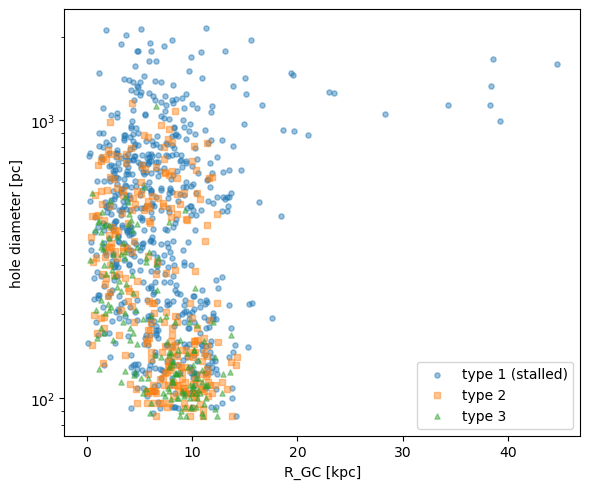

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
for ht, marker, label in [(1, 'o', 'type 1 (stalled)'), (2, 's', 'type 2'), (3, '^', 'type 3')]:
    sub = holes[holes['hole_type'] == ht]
    ax.scatter(sub['gc_radius_kpc'], sub['diameter_pc'], s=14, marker=marker, alpha=0.45, label=label)
ax.set_xlabel('R_GC [kpc]')
ax.set_ylabel('hole diameter [pc]')
ax.set_yscale('log')
ax.legend(loc='best')
fig.tight_layout()

## What this notebook locks

- Confirm that types {2,3} together leave ≥ ~20 holes per galaxy on at
  least 15/19 LOGO folds. If not, revisit §2.4.
- Confirm that diameter range matches `100 pc` to `~2 kpc`. If a galaxy
  has holes outside that range, double-check `Data/J_AJ_141_23/table7.dat`
  alignment in `tests/test_catalog.py`.